# Business Insights

Transforming descriptive visual outputs and statistical distributions from the `customer_churn.csv` dataset into actionable business insights.

In [9]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('customer_churn.csv')

# Clean inconsistent string entries
df['ContractType'] = df['ContractType'].str.replace('Month to month', 'Month-to-month')
df['InternetService'] = df['InternetService'].str.replace('fiber optic', 'Fiber optic')
df['TenureBucket'] = pd.cut(df['TenureYears'], bins=[-1, 1, 3, 6, 10], labels=['0-1 Year', '2-3 Years', '4-6 Years', '7-10 Years'])

sns.set_theme(style="whitegrid")

### Data Anomalies & Data Quality Findings

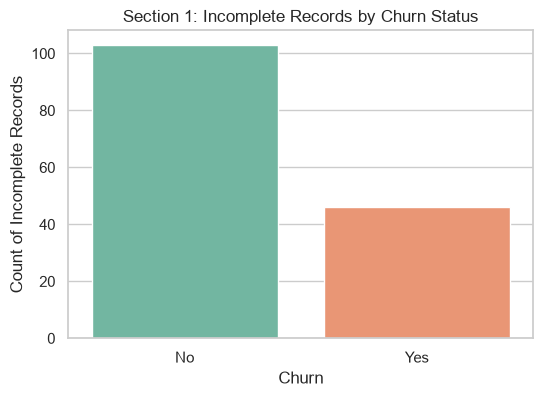

In [11]:
# Missing Values Breakdown by Churn Status
missing_df = df[df.isnull().any(axis=1)]

plt.figure(figsize=(6, 4))
sns.countplot(data=missing_df, x='Churn', hue='Churn', palette='Set2')
plt.title('Section 1: Incomplete Records by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Count of Incomplete Records')
plt.show()

* Inconsistencies detected in string fields (`ContractType` and `InternetService`) along with missing value clusters in financial metrics (`MonthlyCharges`, `TotalCharges`, `Age`).
* `ContractType` contained entry fragmentation (`Month to month` vs `Month-to-month`).
* `InternetService` exhibited capitalization duplicates (`fiber optic` vs `Fiber optic`).
* Missing values were identified across `Age` (51 missing), `MonthlyCharges` (50 missing), and `TotalCharges` (51 missing), affecting ~1% of the record base.



#### Business Impact
Data hygiene gaps in front-end entry forms or legacy CRM syncs dilute pipeline reliability. Standardizing categorical inputs at ingestion prevents inaccurate segment aggregation during automated retention campaigns.

### Trends & Key Patterns


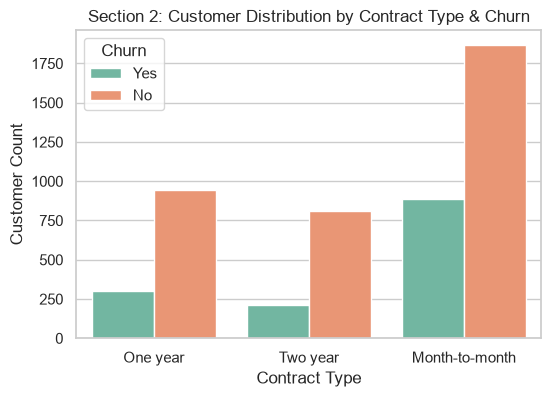

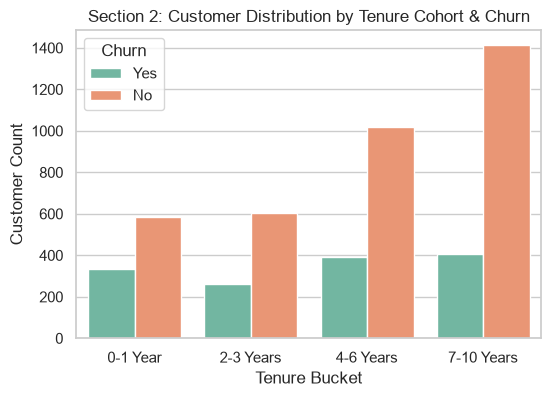

In [12]:
# Churn Breakdown across Contract Types
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='ContractType', hue='Churn', palette='Set2')
plt.title('Section 2: Customer Distribution by Contract Type & Churn')
plt.xlabel('Contract Type')
plt.ylabel('Customer Count')
plt.show()

# Churn Breakdown across Tenure Buckets
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='TenureBucket', hue='Churn', palette='Set2')
plt.title('Section 2: Customer Distribution by Tenure Cohort & Churn')
plt.xlabel('Tenure Bucket')
plt.ylabel('Customer Count')
plt.show()

* **Contract Commitment:** Customers on **Month-to-month** contracts experience a **32.25% churn rate**, compared to **24.03%** for 1-year contracts and **20.53%** for 2-year contracts.
* **Tenure Onboarding:** New customers in their **first year (0–1 Year)** churn at **36.35%**, whereas long-term customers (**7–10 Years**) churn at **22.35%**.

#### Strategic Implication
The initial 12 months represent a critical drop-off window. First-year month-to-month subscribers present the highest flight risk due to low switching friction. Incentivizing early transitions from monthly billing to multi-year contracts reduces customer churn by up to **36% relative risk**.

### Friction Points & Customer Relationships

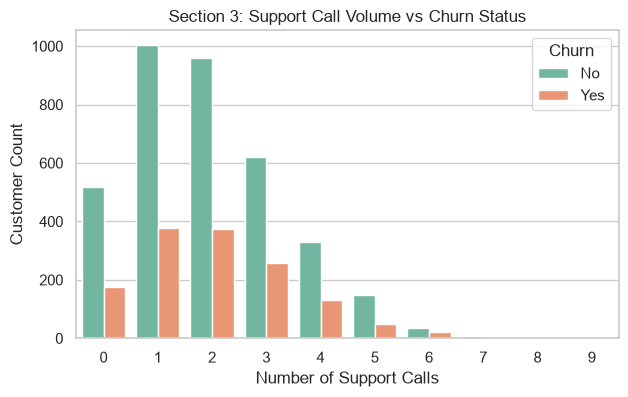

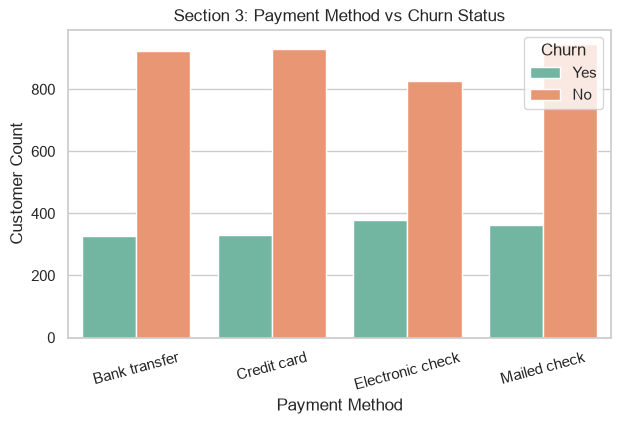

In [14]:
# Churn Breakdown by Number of Support Calls
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='SupportCalls', hue='Churn', palette='Set2')
plt.title('Section 3: Support Call Volume vs Churn Status')
plt.xlabel('Number of Support Calls')
plt.ylabel('Customer Count')
plt.show()

# Churn Breakdown by Payment Method
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='PaymentMethod', hue='Churn', palette='Set2')
plt.title('Section 3: Payment Method vs Churn Status')
plt.xlabel('Payment Method')
plt.ylabel('Customer Count')
plt.xticks(rotation=15)
plt.show()


* **Support Friction Escalation:** Churn remains relatively flat between 0–5 support calls (~25%–29%), but spikes sharply to **39.65% at 6 calls** and **40.00% at 8 calls**.
* **Payment Channel Disparity:** Customers paying via **Electronic Check** churn at **31.42%**, significantly higher than those using **Bank Transfer (26.12%)** or **Credit Card (26.17%)**.

#### Operational Remediation
* **Customer Service SLA:** Escalating support tickets to dedicated retention specialists when a account reaches **4 or 5 support calls** can prevent customer churn before reaching the tipping point (>6 calls).
* **Payment Automation:** Payment failure or friction associated with manual electronic checks increases churn. Transitioning customers to automated clearing (ACH/Credit Card) reduces billing friction.

### High-Risk Customer Segments & Financial Impact

| Business Dimension | Findings & Data Point | Strategic Insight & Root Cause |
| :--- | :--- | :--- |
| **High-Risk Micro-Segment** | Month-to-month + Fiber Optic + Electronic Check exhibits a **40.82% churn rate**. | Premium pricing combined with flexible contract terms and manual billing creates a high-turnover segment. |
| **Financial Exposure (LTV)** | Cumulative lost lifetime revenue stands at **$5,781,824.24** (**24.87%** of total dataset revenue). | Revenue leakage is concentrated in high monthly charge accounts ($70+/month average). |
| **Monthly Exposure (MRR)** | **$96,890.31** in Monthly Recurring Revenue is lost to churn each cycle. | Focus retention dollars on top-decile MRR accounts rather than broad discount campaigns. |

### Strategic Action Plan & Next Steps

#### Immediate Priorities (0–30 Days)
1. **Support Call Early-Warning Trigger:** Implement automated routing rules to flag accounts reaching **4 support calls** for proactive account management outreach.
2. **Data Pipeline Standardization:** Enforce data validation rules upstream to eliminate string variations in `ContractType` and `InternetService`.

#### Medium-Term Initiatives (30–90 Days)
1. **Onboarding & Multi-Year Conversion Campaign:** Target year-1 Month-to-Month accounts with annual contract discounts (e.g., 10% off for 12-month lock-in).
2. **Auto-Pay Migration Incentive:** Offer a one-time $10 bill credit to shift Electronic Check users to automated Credit Card/ACH payment options.

#### Key Performance Indicators (KPIs) to Track
* **First-Year Churn Rate:** Goal < 28% (down from 36.35%).
* **High-Support Customer Retention:** Reduction in churn for accounts with 6+ calls by at least 15%.
* **Payment Auto-Migration Rate:** Transition 25% of Electronic Check users to auto-pay.